In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from rdkit import Chem
from rdkit.Chem import Draw

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
df = pd.read_csv("tox21.csv")
print(df.shape)
df.head()

(7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [3]:
df = df.replace(" ", np.nan)

label_df = df.drop(columns=['smiles'])
label_df = label_df.apply(pd.to_numeric, errors='coerce')
print(label_df.dtypes)

NR-AR            float64
NR-AR-LBD        float64
NR-AhR           float64
NR-Aromatase     float64
NR-ER            float64
NR-ER-LBD        float64
NR-PPAR-gamma    float64
SR-ARE           float64
SR-ATAD5         float64
SR-HSE           float64
SR-MMP           float64
SR-p53           float64
mol_id           float64
dtype: object


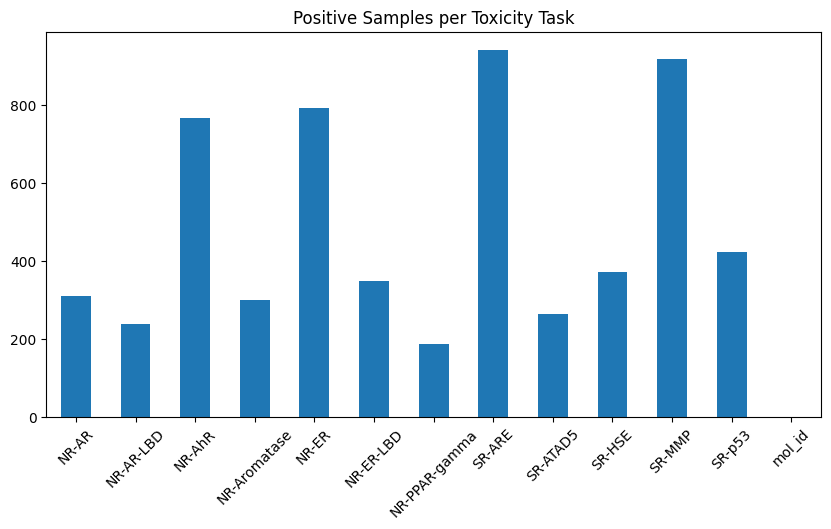

In [4]:
label_counts = label_df.sum()

plt.figure(figsize=(10,5))
label_counts.plot(kind='bar')
plt.title("Positive Samples per Toxicity Task")
plt.xticks(rotation=45)
plt.show()

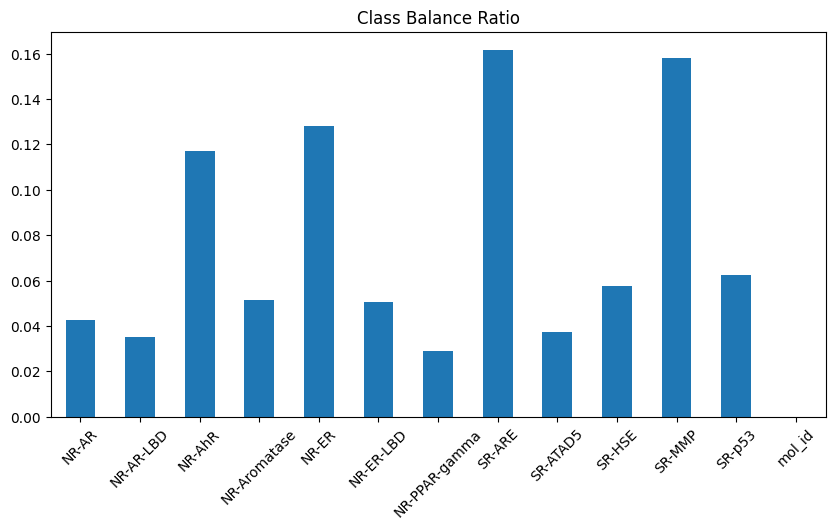

In [5]:
balance = label_df.mean()

plt.figure(figsize=(10,5))
balance.plot(kind='bar')
plt.title("Class Balance Ratio")
plt.xticks(rotation=45)
plt.show()

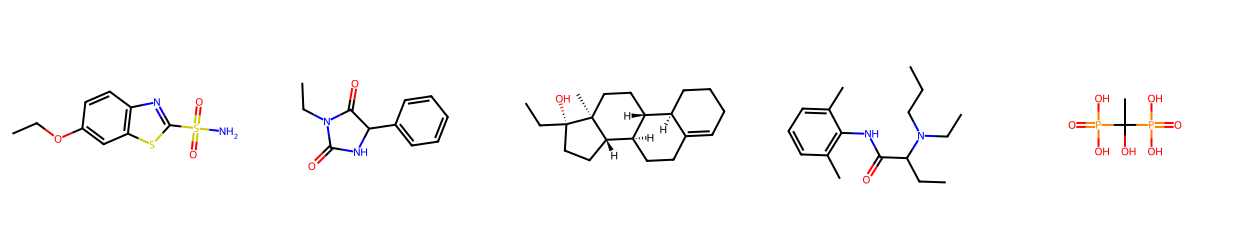

In [6]:
sample_smiles = df['smiles'].iloc[:5]
mols = [Chem.MolFromSmiles(sm) for sm in sample_smiles]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(250,250))

In [7]:
labels = label_df.values.astype(float)

mask = ~np.isnan(labels)
labels = np.nan_to_num(labels, nan=0.0)

smiles_list = df['smiles'].values

In [8]:
label_tensor = torch.tensor(labels)

pos_counts = label_tensor.sum(dim=0)
neg_counts = label_tensor.shape[0] - pos_counts
pos_weight = (neg_counts / (pos_counts + 1e-8)).float()
pos_weight = torch.clamp(pos_weight, max=10)

print("pos_weight:", pos_weight)

pos_weight: tensor([10.0000, 10.0000,  9.1966, 10.0000,  8.8752, 10.0000, 10.0000,  7.3132,
        10.0000, 10.0000,  7.5305, 10.0000, 10.0000])


In [9]:
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic())
    ]

def smiles_to_graph(smiles, label, mask_row):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x, edge_index = [], []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    return Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        y=torch.tensor(label, dtype=torch.float).unsqueeze(0),
        mask=torch.tensor(mask_row, dtype=torch.bool).unsqueeze(0)
    )

In [10]:
dataset = []

for sm, lab, m in zip(smiles_list, labels, mask):
    g = smiles_to_graph(sm, lab, m)
    if g:
        dataset.append(g)

print("Graphs:", len(dataset))

[11:38:23] WARNING: not removing hydrogen atom without neighbors
[11:38:23] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:38:24] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:38:24] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:38:24] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:38:25] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:38:25] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:38:25] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:38:26] Explicit valence for atom # 20 Al, 6, is greater than permitted


Graphs: 7823


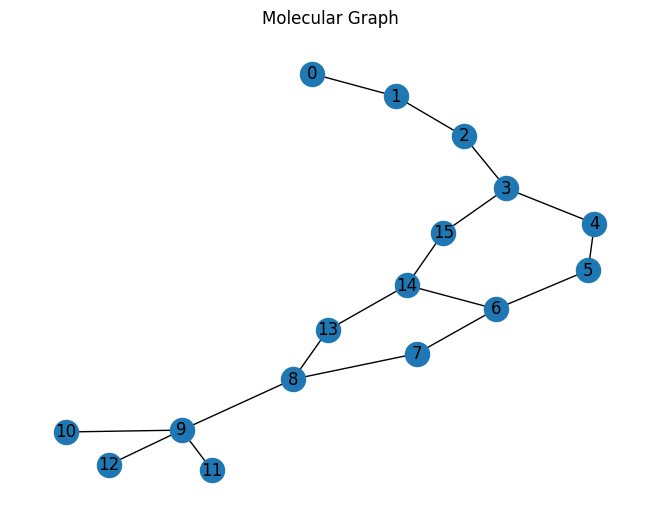

In [11]:
def visualize_graph(data):
    G = nx.Graph()
    edge_index = data.edge_index.numpy()

    for i in range(edge_index.shape[1]):
        G.add_edge(edge_index[0][i], edge_index[1][i])

    nx.draw(G, with_labels=True)
    plt.title("Molecular Graph")
    plt.show()

visualize_graph(dataset[0])

In [43]:
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [44]:
class ToxicityGAT(nn.Module):
    def __init__(self, num_features, num_outputs):
        super().__init__()
        self.gat1 = GATConv(num_features, 64, heads=4)
        self.gat2 = GATConv(64*4, 128, heads=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_outputs)

    def forward(self, x, edge_index, batch, return_attention=False):
        x, attn1 = self.gat1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x = self.dropout(x)
        x, attn2 = self.gat2(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        pooled = global_mean_pool(x, batch)
        out = self.fc(pooled)

        if return_attention:
            return out, attn1, attn2

        return out

In [45]:
num_features = dataset[0].num_node_features
num_outputs = labels.shape[1]

model = ToxicityGAT(num_features, num_outputs)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

In [46]:
def masked_loss(pred, target, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        pred, target,
        reduction='none',
        pos_weight=pos_weight
    )
    loss = loss * mask.float()
    return loss.sum() / (mask.sum() + 1e-8)

In [47]:
batch = next(iter(train_loader))

print("Output shape:", model(batch.x, batch.edge_index, batch.batch).shape)
print("Target shape:", batch.y.shape)
print("Mask shape:", batch.mask.shape)

Output shape: torch.Size([32, 13])
Target shape: torch.Size([32, 13])
Mask shape: torch.Size([32, 13])


In [48]:
def train():
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = masked_loss(out, batch.y, batch.mask, pos_weight)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss

In [49]:
def evaluate(loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            out = torch.sigmoid(out)  # convert logits → probability
            preds.append(out)
            trues.append(batch.y)
    preds = torch.cat(preds).cpu().numpy()
    trues = torch.cat(trues).cpu().numpy()
    aucs = []

    for i in range(trues.shape[1]):
        if len(np.unique(trues[:, i])) < 2:
            continue
        aucs.append(roc_auc_score(trues[:, i], preds[:, i]))

    return preds, trues, np.mean(aucs)

In [50]:
batch = next(iter(train_loader))

print("Pred:", model(batch.x, batch.edge_index, batch.batch).shape)
print("Target:", batch.y.shape)
print("Mask:", batch.mask.shape)

Pred: torch.Size([32, 13])
Target: torch.Size([32, 13])
Mask: torch.Size([32, 13])


In [52]:
loss_history = []
auc_history = []
best_auc = 0

for epoch in range(50):
    loss = train()
    preds, trues, auc = evaluate(test_loader)
    loss_history.append(loss)
    auc_history.append(auc)
    if auc > best_auc:
        best_auc = auc

    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | AUC: {auc:.4f} | Best: {best_auc:.4f}")

Epoch 1 | Loss: 166.5607 | AUC: 0.7628 | Best: 0.7628
Epoch 2 | Loss: 165.4417 | AUC: 0.7618 | Best: 0.7628
Epoch 3 | Loss: 166.7804 | AUC: 0.7646 | Best: 0.7646
Epoch 4 | Loss: 166.1606 | AUC: 0.7657 | Best: 0.7657
Epoch 5 | Loss: 165.4133 | AUC: 0.7672 | Best: 0.7672
Epoch 6 | Loss: 164.7553 | AUC: 0.7681 | Best: 0.7681
Epoch 7 | Loss: 165.8134 | AUC: 0.7662 | Best: 0.7681
Epoch 8 | Loss: 164.6120 | AUC: 0.7692 | Best: 0.7692
Epoch 9 | Loss: 164.9472 | AUC: 0.7675 | Best: 0.7692
Epoch 10 | Loss: 164.6157 | AUC: 0.7679 | Best: 0.7692
Epoch 11 | Loss: 164.1120 | AUC: 0.7714 | Best: 0.7714
Epoch 12 | Loss: 164.3833 | AUC: 0.7665 | Best: 0.7714
Epoch 13 | Loss: 164.6600 | AUC: 0.7670 | Best: 0.7714
Epoch 14 | Loss: 164.0511 | AUC: 0.7644 | Best: 0.7714
Epoch 15 | Loss: 163.6163 | AUC: 0.7697 | Best: 0.7714
Epoch 16 | Loss: 163.9919 | AUC: 0.7680 | Best: 0.7714
Epoch 17 | Loss: 163.1852 | AUC: 0.7714 | Best: 0.7714
Epoch 18 | Loss: 162.8351 | AUC: 0.7693 | Best: 0.7714
Epoch 19 | Loss: 16

In [53]:
def get_attention_weights(graph):
    model.eval()

    x = graph.x
    edge_index = graph.edge_index
    batch = torch.zeros(x.size(0), dtype=torch.long)

    with torch.no_grad():
        out, attn1, attn2 = model(x, edge_index, batch, return_attention=True)
    edge_idx, attn_scores = attn2

    return edge_idx, attn_scores.squeeze().cpu().numpy()

In [54]:
def compute_node_importance(edge_index, attn_scores, num_nodes):
    importance = np.zeros(num_nodes)

    for i in range(edge_index.shape[1]):
        src = edge_index[0][i]
        dst = edge_index[1][i]
        importance[src] += attn_scores[i]
        importance[dst] += attn_scores[i]
    importance = importance / (importance.max() + 1e-8)

    return importance

In [55]:
def visualize_attention(smiles, importance):
    mol = Chem.MolFromSmiles(smiles)
    colors = {
        i: (1, 0, 0, float(importance[i]))
        for i in range(len(importance))
    }
    img = Draw.MolToImage(
        mol,
        highlightAtoms=list(range(len(importance))),
        highlightAtomColors=colors
    )

    plt.imshow(img)
    plt.axis('off')
    plt.title("Attention Map (Red = Important Atoms)")
    plt.show()


Molecule 1


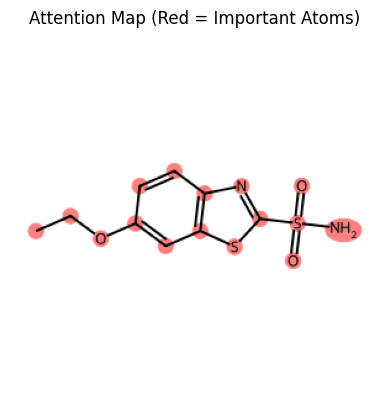


Molecule 2


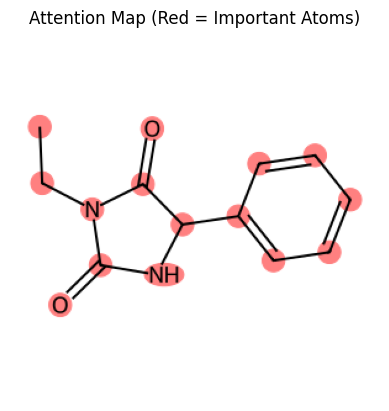


Molecule 3


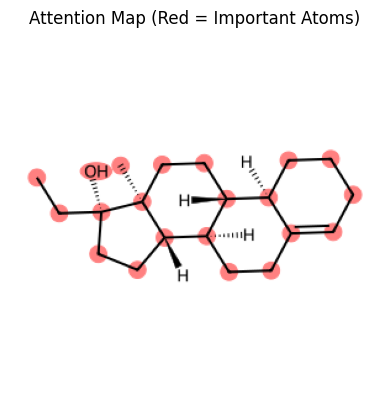


Molecule 4


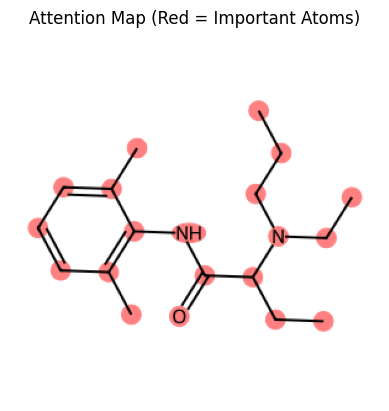


Molecule 5


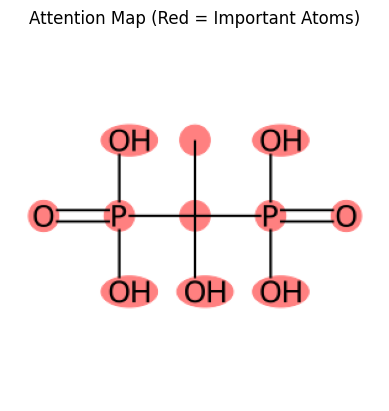


Molecule 6


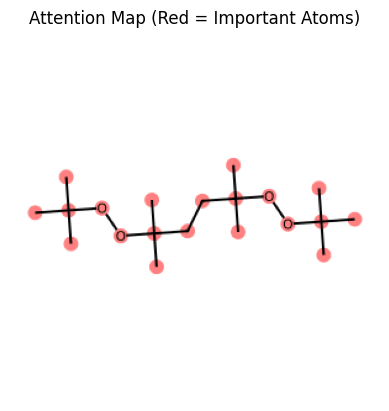


Molecule 7


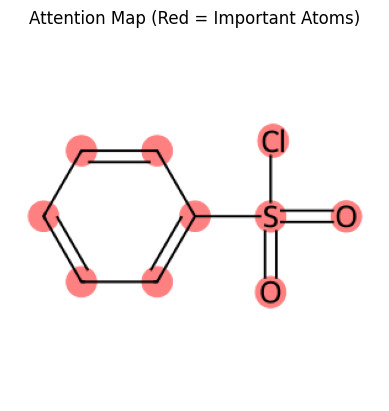


Molecule 8


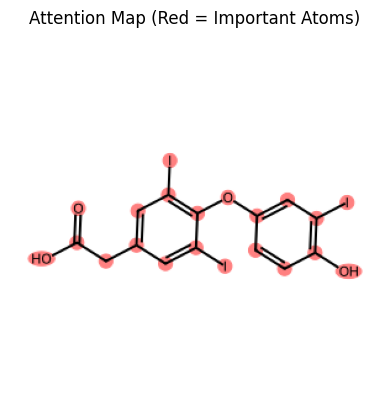


Molecule 9


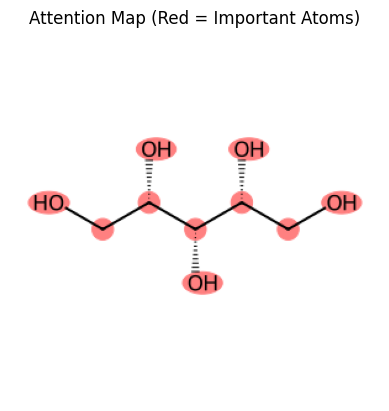


Molecule 10


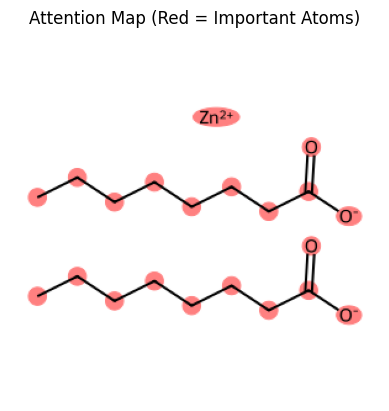

In [56]:
for i in range(10):
    graph = dataset[i]
    smiles = smiles_list[i]
    edge_index, attn_scores = get_attention_weights(graph)
    importance = compute_node_importance(
        edge_index.numpy(),
        attn_scores,
        graph.x.shape[0]
    )

    print(f"\nMolecule {i+1}")
    visualize_attention(smiles, importance)

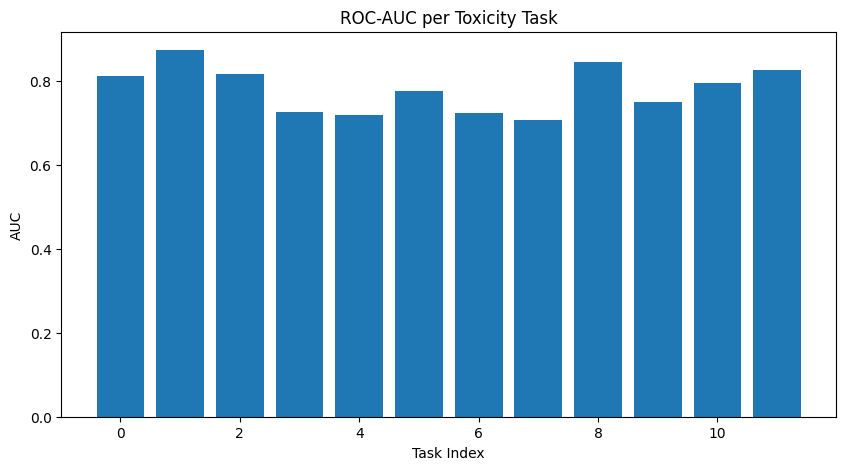

In [57]:
auc_per_task = []

for i in range(trues.shape[1]):
    y_true = trues[:, i]
    y_pred = preds[:, i]

    if len(np.unique(y_true)) < 2:
        auc_per_task.append(np.nan)
    else:
        auc_per_task.append(roc_auc_score(y_true, y_pred))

plt.figure(figsize=(10,5))
plt.bar(range(len(auc_per_task)), auc_per_task)
plt.title("ROC-AUC per Toxicity Task")
plt.xlabel("Task Index")
plt.ylabel("AUC")
plt.show()

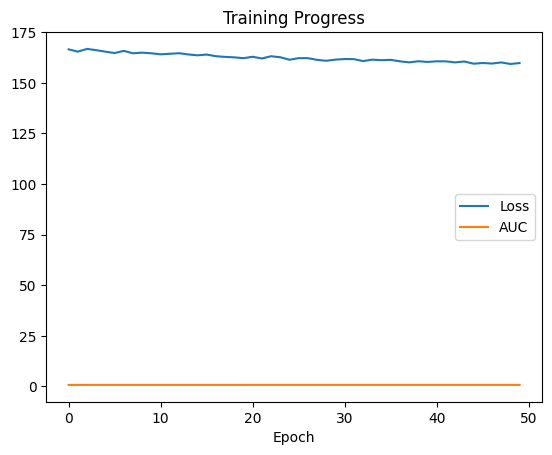

In [58]:
plt.figure()
plt.plot(loss_history, label="Loss")
plt.plot(auc_history, label="AUC")

plt.xlabel("Epoch")
plt.title("Training Progress")
plt.legend()
plt.show()

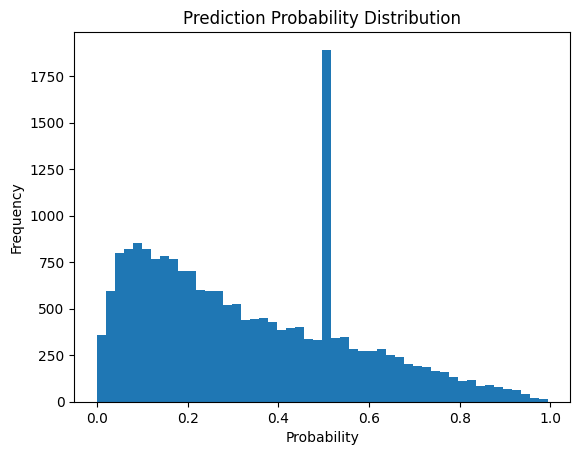

In [59]:
plt.figure()
plt.hist(preds.flatten(), bins=50)

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

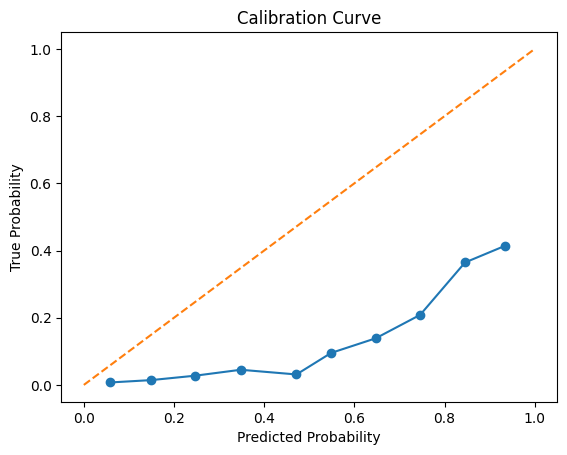

In [60]:
from sklearn.calibration import calibration_curve

y_true = trues.flatten()
y_pred = preds.flatten()
mask_valid = ~np.isnan(y_true)
y_true = y_true[mask_valid]
y_pred = y_pred[mask_valid]

prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()

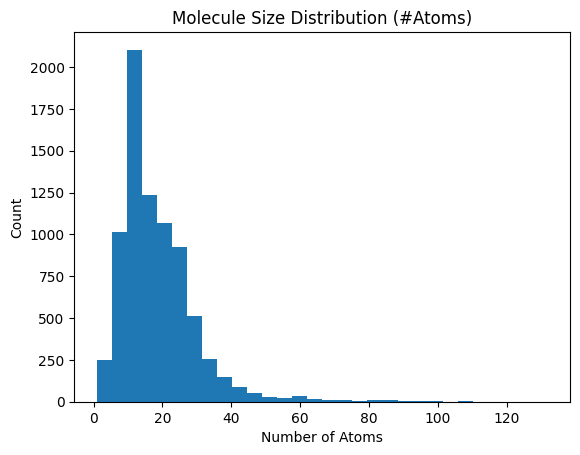

In [61]:
sizes = [g.x.shape[0] for g in dataset]
plt.figure()
plt.hist(sizes, bins=30)

plt.title("Molecule Size Distribution (#Atoms)")
plt.xlabel("Number of Atoms")
plt.ylabel("Count")
plt.show()

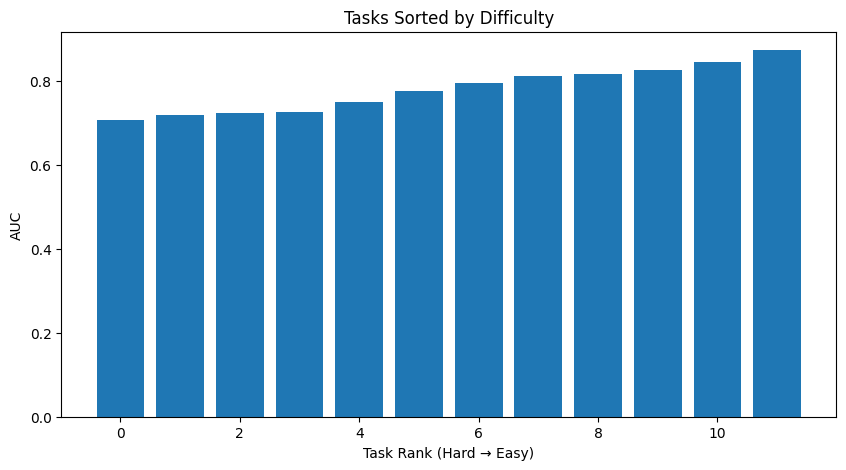

In [62]:
task_indices = np.arange(len(auc_per_task))
sorted_idx = np.argsort(auc_per_task)

plt.figure(figsize=(10,5))
plt.bar(range(len(auc_per_task)), np.array(auc_per_task)[sorted_idx])

plt.title("Tasks Sorted by Difficulty")
plt.xlabel("Task Rank (Hard → Easy)")
plt.ylabel("AUC")
plt.show()

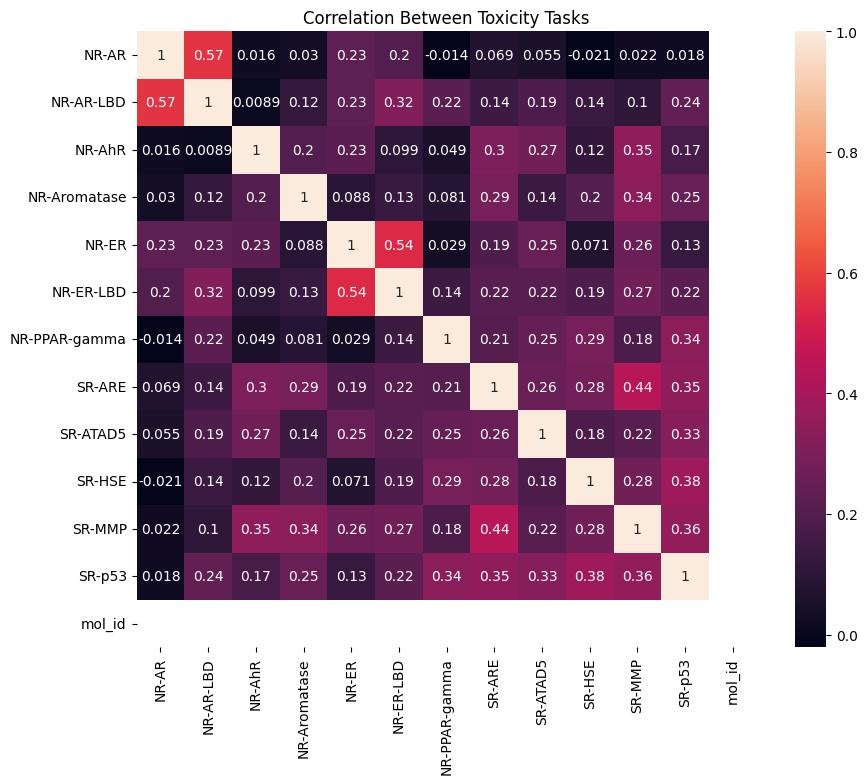

In [63]:
import seaborn as sns

corr = label_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Toxicity Tasks")
plt.show()

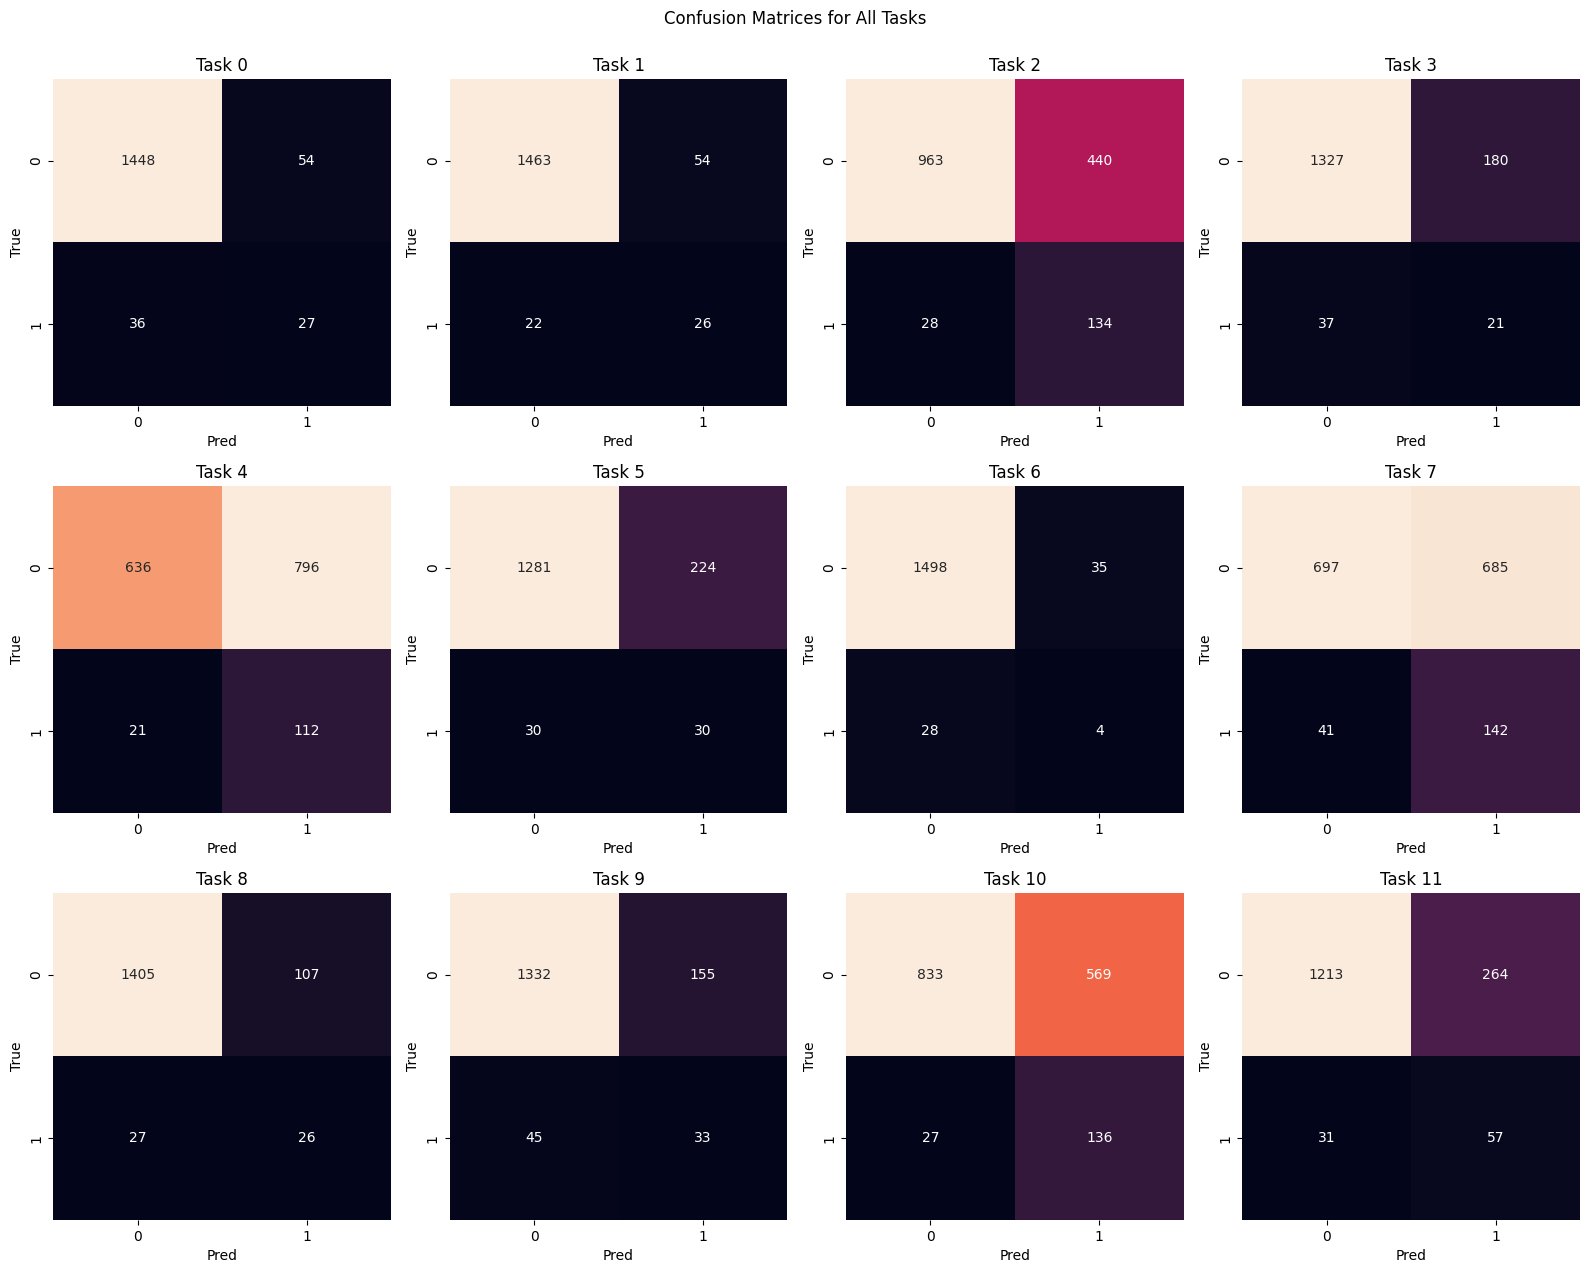

In [64]:
from sklearn.metrics import confusion_matrix

num_tasks = trues.shape[1]
cols = 4  
rows = int(np.ceil(num_tasks / cols))
plt.figure(figsize=(cols*4, rows*4))

for i in range(num_tasks):
    y_true = trues[:, i]
    y_pred = (preds[:, i] > 0.5).astype(int)
    
    if len(np.unique(y_true)) < 2:
        continue

    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(rows, cols, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"Task {i}")
    plt.xlabel("Pred")
    plt.ylabel("True")

plt.tight_layout()
plt.suptitle("Confusion Matrices for All Tasks", y=1.02)
plt.show()

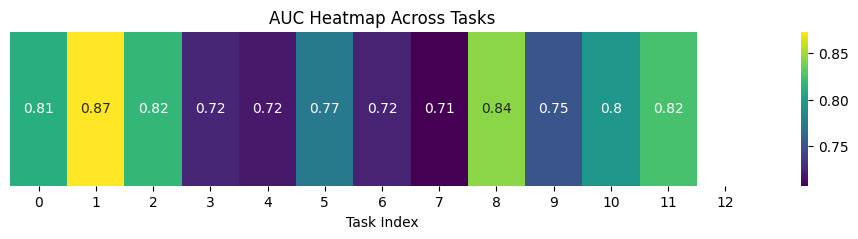

In [65]:
auc_array = np.array(auc_per_task).reshape(1, -1)

plt.figure(figsize=(12,2))
sns.heatmap(auc_array, annot=True, cmap="viridis")

plt.title("AUC Heatmap Across Tasks")
plt.yticks([])
plt.xlabel("Task Index")
plt.show()

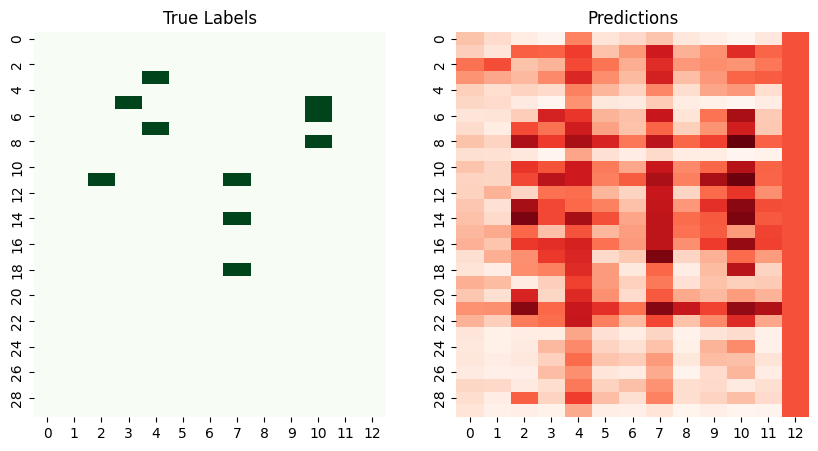

In [66]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.heatmap(trues[:30], cmap="Greens", cbar=False)
plt.title("True Labels")

plt.subplot(1,2,2)
sns.heatmap(preds[:30], cmap="Reds", cbar=False)
plt.title("Predictions")
plt.show()

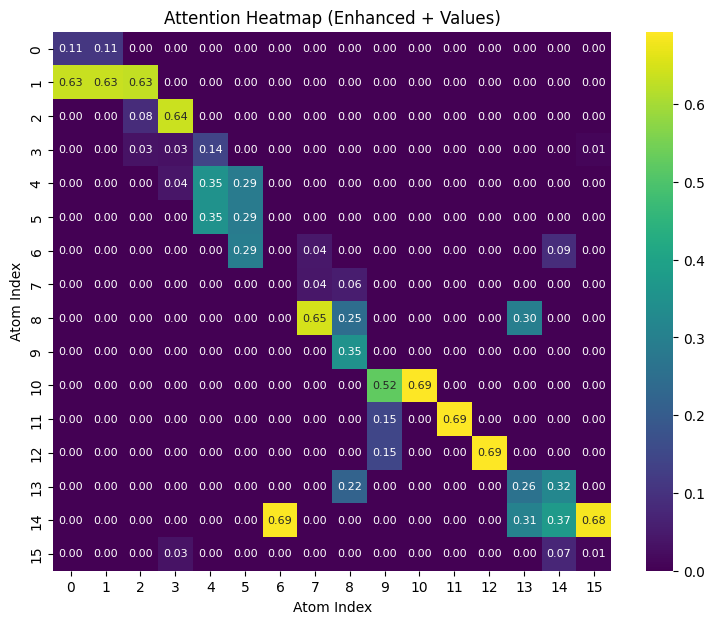

In [67]:
edge_index, attn_scores = get_attention_weights(dataset[0])
num_nodes = dataset[0].x.shape[0]
matrix = np.zeros((num_nodes, num_nodes))

for i in range(edge_index.shape[1]):
    src = edge_index[0][i]
    dst = edge_index[1][i]
    matrix[src][dst] = attn_scores[i]
    
matrix = matrix / (matrix.max() + 1e-8)
matrix = np.log1p(matrix)

plt.figure(figsize=(9,7))
sns.heatmap(matrix, cmap="viridis", annot=True,
    fmt=".2f", annot_kws={"size":8})

plt.title("Attention Heatmap (Enhanced + Values)")
plt.xlabel("Atom Index")
plt.ylabel("Atom Index")
plt.show()

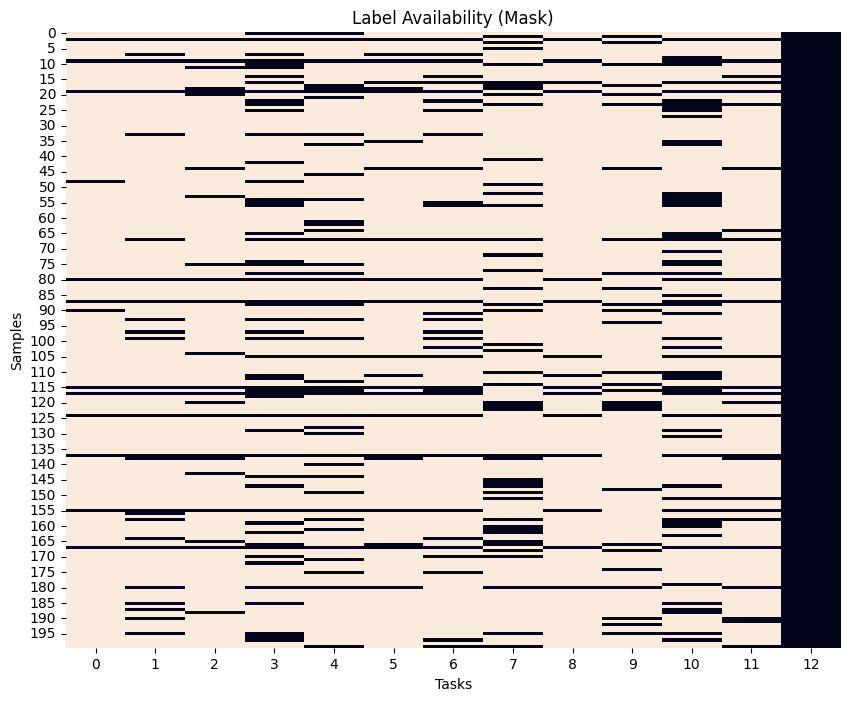

In [68]:
plt.figure(figsize=(10,8))
sns.heatmap(mask[:200], cbar=False)

plt.title("Label Availability (Mask)")
plt.xlabel("Tasks")
plt.ylabel("Samples")
plt.show()

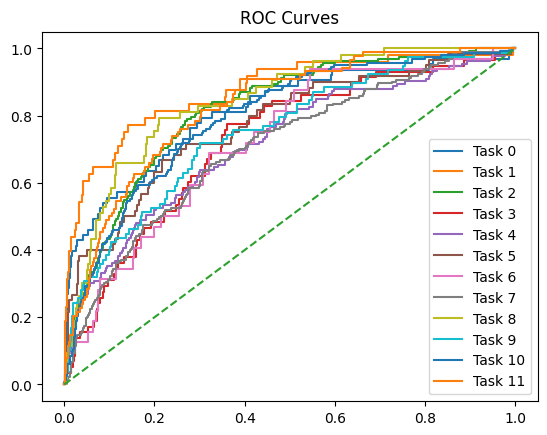

In [69]:
for i in range(trues.shape[1]):
    if len(np.unique(trues[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(trues[:, i], preds[:, i])
    plt.plot(fpr, tpr, label=f'Task {i}')

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curves")
plt.show()

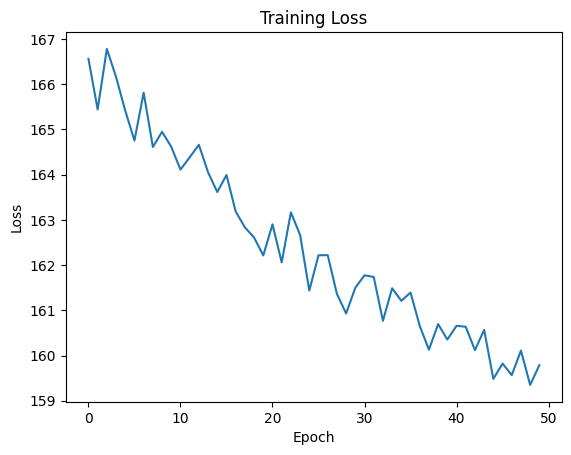

In [70]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [71]:
torch.save({
    "model_state_dict": model.state_dict(),
    "num_features": num_features,
    "num_outputs": num_outputs
}, "best_model.pth")

In [72]:
checkpoint = torch.load("best_model.pth", map_location=torch.device("cpu"))
model = ToxicityGAT(
    checkpoint["num_features"],
    checkpoint["num_outputs"])

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ToxicityGAT(
  (gat1): GATConv(5, 64, heads=4)
  (gat2): GATConv(256, 128, heads=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=13, bias=True)
)

In [73]:
# test load
model.load_state_dict(torch.load("best_model.pth")["model_state_dict"])
print("Model loaded successfully!")

Model loaded successfully!
